# Exploring the Data Generation Process Using Python and Pandas

## 📚 Learning Objectives

By completing this notebook, you will:
- Explore the **data-generating process** behind a real dataset
- Use Python and Pandas to read and profile real data
- Understand real data distributions — skew, bounds and missingness
- See why real columns rarely look like the tidy bell curves in textbooks
- Apply this profiling habit to ML scenarios

## 🔗 Where this fits

**Builds on:** Unit 2, lesson 07 "Encoding Categorical Features for ML Models" — before you encode a column you have to know how it was generated.

**Used later in:** Course 05 (AIAT 115) — Unit 2, the full data-cleaning unit that starts from exactly this profiling habit.

---

This notebook covers practical activities from **Course 01, Unit 2**:
- Exploring the data generation process using Python and Pandas

---

## Introduction

Every dataset is the fingerprint of a **real process in the world**. Somebody decided what
to record, somebody wrote it down, and some records went missing. That chain of events is
the **data-generating process (DGP)**.

We explore it here on the **Titanic passenger manifest** — 891 real passengers from the
1912 voyage, with the ticket class, fare, age and survival outcome that clerks actually
recorded. Reading the distributions tells you what the process was really like, and the
gaps tell you where the process broke down.


## 🎯 When the process changed and the model did not notice

**Google Flu Trends** launched in 2008 and was, for a while, the standard example
of big data beating institutions: it estimated flu prevalence from search queries,
faster than the US Centers for Disease Control could publish its own figures.

Then it broke. In March 2014, David Lazer and colleagues published *The Parable
of Google Flu: Traps in Big Data Analysis* in **Science**. Their finding: for the
2012-13 season Google Flu Trends estimated **more than double** the CDC's measured
rate of influenza-like illness, and across the two years from August 2011 it ran
too high in **100 out of 108 weeks**.

The model had not decayed. Its **data-generating process** had changed underneath
it. The correlations were fitted to a period when a search for "cough" mostly
meant a person with a cough; afterwards, media coverage of flu drove searches from
people who were not ill, and Google's own product changes — related searches,
autocomplete suggestions — altered what people typed. The measuring instrument
was being reshaped by the thing it was embedded in, and the model had no way to
know.

That is why this notebook profiles a dataset before modelling anything. The
Titanic manifest below has a fixed, closed data-generating process — clerks in
1912, a voyage that ended — which makes it the ideal place to practise reading a
process off its data. What you learn here is what you will use on a live feed,
where the process is still moving.

### What goes wrong without profiling first

You compute the mean fare (**£32.20**), quote it as "the typical ticket", and are
wrong by more than a factor of two — the median is **£14.45**, because a handful
of passengers paid up to £512.33. You impute the missing ages with that mean and
erase the pattern in who is missing. You train on a manifest that is 65% male and
report a single accuracy figure. Every one of those is a decision made by
*not* looking, and the printouts below make each of them visible.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Load a REAL dataset and let the data-generating process speak for itself.
# The Titanic manifest was produced by clerks in 1912: what they recorded, how they
# recorded it, and what they failed to record are all visible in the columns below.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported!")
print("\nExploring the Data Generation Process")
print("=" * 60)

# Read the real CSV shipped with this diploma (no internet required).
df = pd.read_csv("../../../Course 04/datasets/raw/titanic.csv")

print("\nReal dataset (Titanic passenger manifest, 1912):")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")

print("\n✅ Real dataset loaded!")
print("\n💡 Nobody chose these numbers. Every row is a person who bought a ticket.")

✅ Libraries imported!

Exploring the Data Generation Process

Real dataset (Titanic passenger manifest, 1912):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S

In [2]:
# Profile the real distributions. Unlike an invented dataset, nothing here was drawn
# from a neat bell curve — so describe() shows us what the WORLD produced, including
# hard bounds, heavy skew and outliers we did not put there on purpose.
print("=" * 60)
print("REAL DATA DISTRIBUTIONS")
print("=" * 60)

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
print("\nStatistical Summary:")
print(df[numeric_cols].describe())

# Skewness measures asymmetry: 0 = symmetric bell curve, large positive = long right tail.
print("\n\nSkewness of each numeric column (0 would mean a symmetric bell curve):")
for col in numeric_cols:
    print(f"  {col:6s}: {df[col].skew():+.2f}")

print("\n\nCategorical Distributions (real, and far from balanced):")
for col in ["Pclass", "Sex", "Embarked"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

print("\n✅ Data exploration completed!")

REAL DATA DISTRIBUTIONS

Statistical Summary:
              Age        Fare       SibSp       Parch
count  714.000000  891.000000  891.000000  891.000000
mean    29.699118   32.204208    0.523008    0.381594
std     14.526497   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     20.125000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     38.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000


Skewness of each numeric column (0 would mean a symmetric bell curve):
  Age   : +0.39
  Fare  : +4.79
  SibSp : +3.70
  Parch : +2.75


Categorical Distributions (real, and far from balanced):

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

✅ Data exploration completed!


### 🔎 Where the process broke down: real missing values

An invented dataset is complete by construction. A real one is not. Missingness is
**part of the data-generating process** — it tells you which facts the clerks could not
or did not record, and that pattern is itself information.

In [3]:
# Count the real gaps. These are not simulated holes — they are facts that were never
# written down in 1912, and every ML pipeline you build later must decide what to do with them.
print("=" * 60)
print("MISSINGNESS: THE PART OF THE PROCESS THAT FAILED")
print("=" * 60)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nColumns with missing values:")
for col, n in missing.items():
    print(f"  {col:10s}: {n:4d} missing ({n / len(df) * 100:5.1f}% of rows)")

print("\n💡 The Cabin column is mostly empty because cabin numbers were mainly recorded")
print("   for higher-paying passengers. The missingness itself carries class information —")
print("   which is exactly why you must never delete it without thinking.")

# Evidence for that claim, straight from the data:
cabin_known_by_class = df.assign(cabin_known=df["Cabin"].notna()).groupby("Pclass")["cabin_known"].mean()
print("\nProportion of passengers with a recorded cabin, by ticket class:")
for pclass, frac in cabin_known_by_class.items():
    print(f"  Class {pclass}: {frac * 100:5.1f}%")

MISSINGNESS: THE PART OF THE PROCESS THAT FAILED

Columns with missing values:
  Cabin     :  687 missing ( 77.1% of rows)
  Age       :  177 missing ( 19.9% of rows)
  Embarked  :    2 missing (  0.2% of rows)

💡 The Cabin column is mostly empty because cabin numbers were mainly recorded
   for higher-paying passengers. The missingness itself carries class information —
   which is exactly why you must never delete it without thinking.

Proportion of passengers with a recorded cabin, by ticket class:
  Class 1:  81.5%
  Class 2:   8.7%
  Class 3:   2.4%


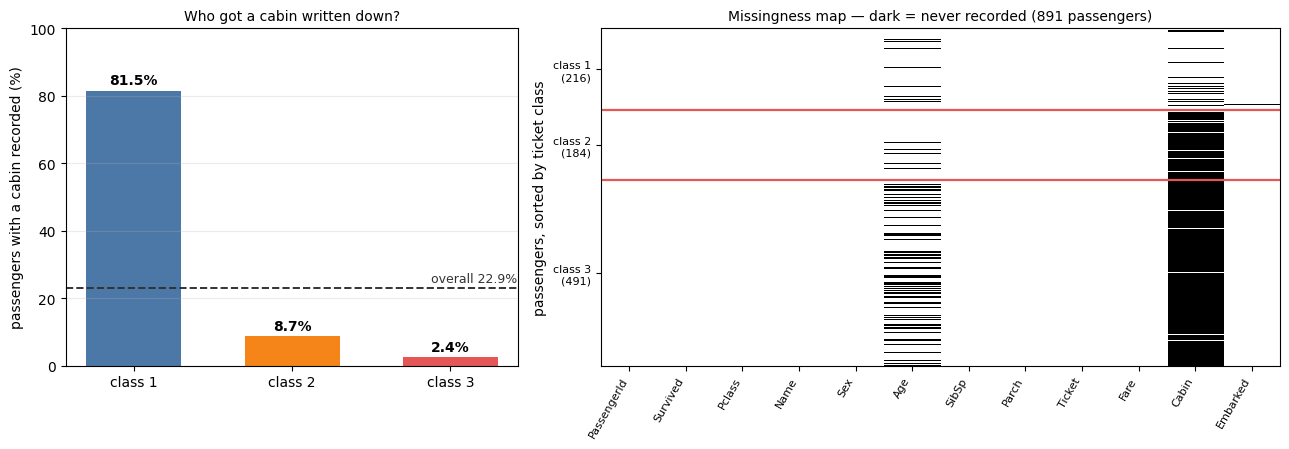

Recorded-cabin rate by ticket class (the left panel, as numbers):
  class 1:  81.5%
  class 2:   8.7%
  class 3:   2.4%

Cabin missing overall : 687 of 891 (77.1%)
Age   missing overall : 177 of 891 (19.9%)
Age missing by class  : class 1 13.9%  class 2 6.0%  class 3 27.7%


In [4]:
# 📊 FIGURE — missingness is not noise; it has a shape, and the shape is class.
# WHAT: exactly the numbers printed above, drawn. Left = the proportion of passengers
#       with a cabin recorded, split by ticket class. Right = the raw missingness map:
#       one row per passenger (sorted by class), one column per field, white where the
#       1912 clerk recorded a value and dark where the record is blank.
# WHY: a list of counts tells you HOW MUCH is missing. Only the map tells you WHO is
#      missing — and that is the part that will bias a model you build on this file.
import matplotlib.pyplot as plt
import numpy as np

cabin_by_class = df.assign(k=df["Cabin"].notna()).groupby("Pclass")["k"].mean() * 100

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6),
                               gridspec_kw={"width_ratios": [1, 1.5]})

# --- LEFT: recorded-cabin rate by ticket class -----------------------------
bars = axL.bar([f"class {c}" for c in cabin_by_class.index], cabin_by_class.values,
               color=["#4C78A8", "#F58518", "#E45756"], width=0.6)
for b, v in zip(bars, cabin_by_class.values):
    axL.text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.1f}%",
             ha="center", fontweight="bold")
overall = df["Cabin"].notna().mean() * 100
axL.axhline(overall, color="#333", ls="--", lw=1.4)
axL.text(2.42, overall + 2, f"overall {overall:.1f}%", ha="right", fontsize=9, color="#333")
axL.set_ylim(0, 100); axL.set_ylabel("passengers with a cabin recorded (%)")
axL.set_title("Who got a cabin written down?", fontsize=10)
axL.grid(axis="y", alpha=0.25)

# --- RIGHT: the missingness map, passengers sorted by class ----------------
ordered = df.sort_values(["Pclass"], kind="stable")
miss = ordered.isna().to_numpy().astype(float)      # True = the value was never recorded
axR.imshow(miss, aspect="auto", cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
axR.set_xticks(range(len(ordered.columns)))
axR.set_xticklabels(ordered.columns, rotation=60, ha="right", fontsize=8)
boundary = 0
for c in sorted(ordered["Pclass"].unique())[:-1]:
    boundary += int((ordered["Pclass"] == c).sum())
    axR.axhline(boundary, color="#E45756", lw=1.6)
mids, start = [], 0
for c in sorted(ordered["Pclass"].unique()):
    n = int((ordered["Pclass"] == c).sum())
    mids.append((start + n / 2, f"class {c}\n({n})"))
    start += n
axR.set_yticks([m[0] for m in mids])
axR.set_yticklabels([m[1] for m in mids], fontsize=8)
axR.set_ylabel("passengers, sorted by ticket class")
axR.set_title(f"Missingness map — dark = never recorded ({len(ordered)} passengers)",
              fontsize=10)

plt.tight_layout()
plt.show()

print("Recorded-cabin rate by ticket class (the left panel, as numbers):")
for c, v in cabin_by_class.items():
    print(f"  class {c}: {v:5.1f}%")
print(f"\nCabin missing overall : {df['Cabin'].isna().sum()} of {len(df)} "
      f"({df['Cabin'].isna().mean() * 100:.1f}%)")
print(f"Age   missing overall : {df['Age'].isna().sum()} of {len(df)} "
      f"({df['Age'].isna().mean() * 100:.1f}%)")
print(f"Age missing by class  : "
      + "  ".join(f"class {c} {v * 100:.1f}%"
                  for c, v in df.groupby('Pclass')['Age'].apply(lambda s: s.isna().mean()).items()))

### 👁️ Read the figure

**Left — the Cabin column is not missing at random, it is missing by class.** A
first-class passenger has a cabin recorded **81.5%** of the time; a third-class
passenger, **2.4%**. The dashed line is the overall rate, **22.9%**, and notice
that it describes no class at all — it is the average of three groups that have
almost nothing in common. Whatever you do with this column, you are doing it
mostly to third-class passengers.

**Right — the same fact, without any aggregation.** Every row is one real
passenger, sorted into their ticket class; every dark pixel is a value the 1912
clerk never wrote down. Two things jump out of the map:

- The **Cabin** column is a near-solid dark block below the first red line, and
  mostly white above it. That vertical stripe is the class structure of the
  missingness, visible without computing a single statistic.
- The **Age** column is speckled rather than blocked, and the speckle is heaviest
  in class 3. The rates printed under the plot are 13.9% / 6.0% / 27.7% for
  classes 1 / 2 / 3 — not a clean gradient, but plainly not random either. A
  different mechanism from Cabin, still tied to who the passenger was.
- Every other column is white except **Embarked**, which is missing for exactly
  **2** of the 891 passengers — two pixels you cannot see at this scale, and a
  reminder that the map shows you structure, not small counts. Read it beside the
  printed tally, never instead of it.

**What this proves — and why it decides Discuss question 1.** "Drop the column,
fill the gaps, or add a `cabin_was_recorded` flag" is not a tidiness choice. The
map shows that `Cabin` is missing *because of* something the model will later be
asked to predict with. Deleting it deletes a class signal; imputing it invents
cabin numbers for people who never had one recorded; keeping the flag keeps the
signal and makes it explicit. Only the third option leaves the data-generating
process legible to whoever reads your work next.

### 📊 Seeing the shape of a real process

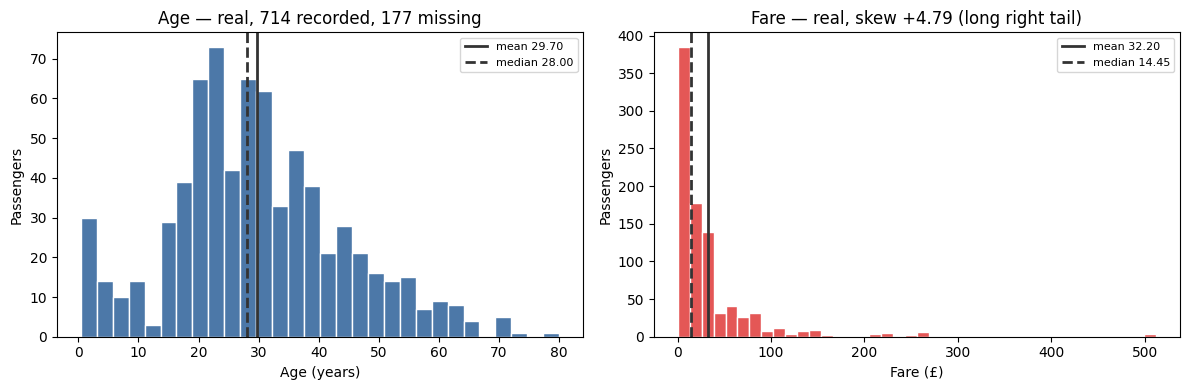

Cheapest ticket: £0.00    Median: £14.45    Most expensive: £512.33

💡 Median and maximum are far apart. That gap is what a real, unequal process
   looks like — and it is the reason the MEAN fare would mislead you here.


In [5]:
# Plot the two most informative numeric columns. Compare the shapes: Age is roughly
# bell-like but truncated at 0 and dented by the missing values; Fare is violently
# right-skewed because a handful of passengers paid enormous sums.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Age"].dropna(), bins=30, color="#4C78A8", edgecolor="white")
axes[0].set_title(f"Age — real, {df['Age'].notna().sum()} recorded, {df['Age'].isna().sum()} missing")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Passengers")

axes[1].hist(df["Fare"], bins=40, color="#E45756", edgecolor="white")
axes[1].set_title(f"Fare — real, skew {df['Fare'].skew():+.2f} (long right tail)")
axes[1].set_xlabel("Fare (£)")
axes[1].set_ylabel("Passengers")

# Mark mean against median on BOTH panels. On a symmetric column the two lines sit on
# top of each other; on a skewed one they separate, and the gap is the whole warning.
for ax, col in ((axes[0], "Age"), (axes[1], "Fare")):
    ax.axvline(df[col].mean(), color="#333", ls="-", lw=2,
               label=f"mean {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color="#333", ls="--", lw=2,
               label=f"median {df[col].median():.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Cheapest ticket: £{df['Fare'].min():.2f}    Median: £{df['Fare'].median():.2f}    "
      f"Most expensive: £{df['Fare'].max():.2f}")
print("\n💡 Median and maximum are far apart. That gap is what a real, unequal process")
print("   looks like — and it is the reason the MEAN fare would mislead you here.")

### 👁️ Read the figure

Two histograms, two vertical lines each: solid is the **mean**, dashed is the
**median**.

- **Age** — the two lines are nearly on top of each other (29.70 against 28.00).
  The shape is roughly symmetric, bounded at 0, with a visible bulge of children
  at the left. Either summary describes a typical passenger, and quoting "the
  average age was 30" is honest.
- **Fare** — the two lines are far apart, and *both* sit at the extreme left of
  the axis while the plot keeps going to £512. This is what a skew of **+4.79**
  looks like. The first two bars hold **63%** of the ship (385 and 177 passengers,
  everyone under about £26); the flat tail to the right is a handful of people,
  and it is that tail which drags the mean to £32.20 while half of everyone paid
  £14.45 or less.

**What this proves:** the mean is a summary of "typical" only when the
distribution is roughly symmetric. On `Fare` the mean describes almost nobody —
it lands in the gap *between* the crowd and the rich, where hardly any passenger
actually sits. That is how a correct calculation becomes a false statement, and
the gap between the two lines is the check that catches it.

## 📊 The same column, summarised two ways

`Fare` was described twice in the output above. Read the two summaries against
each other — this is the cheapest comparative experiment in the whole course:

| statistic | Age | Fare |
|---|---|---|
| mean | 29.70 | **32.20** |
| median (50%) | 28.00 | **14.45** |
| max | 80.00 | **512.33** |
| skewness | +0.39 | **+4.79** |

**The conclusion these numbers support:** for `Age`, the mean and median agree to
within two years and the skew is near zero — either summary describes a typical
passenger. For `Fare`, the mean is **more than twice** the median, and the maximum
is thirty-five times the median. Quote "the average fare was £32" and you have
described almost nobody: three quarters of passengers paid £31 or less, and a
handful paying up to £512 dragged the mean upward on their own.

**The rule this establishes:** the mean is only a summary of "typical" when the
distribution is roughly symmetric, and the skewness number tells you whether it
is. Age passes that test; Fare fails it. Reporting a mean without checking is how
a correct calculation becomes a false statement.


## 💬 Discuss

Everything you need is in the printouts above: skewness of Fare **+4.79** against
Age **+0.39**; **687** missing cabins (77.1%); recorded-cabin rates of **81.5% /
8.7% / 2.4%** by ticket class; a median fare of **£14.45** against a maximum of
**£512.33**.

1. **The Cabin column is 77% empty and the emptiness is not random** — first-class
   passengers have a cabin recorded 81.5% of the time, third-class 2.4%. You have
   three options: drop the column, fill the gaps, or add a boolean
   `cabin_was_recorded` feature. Argue for one. Then argue for the option you
   think is second-best, and say what each one destroys.
2. Fare's skew is +4.79 and its minimum is £0.00 — some passengers paid nothing.
   Would you delete those rows as errors, keep them, or investigate? What would
   change your decision, and who in a real project has the authority to make it?
3. Both the Titanic manifest and Google Flu Trends are records of a process.
   One is closed and one was live. **Name a dataset in Saudi practice whose
   generating process is still moving** — and say what you would monitor, monthly,
   to catch the moment it moves.


## Summary

This notebook covered:
- ✅ **The data-generating process**: reading a real dataset as the fingerprint of a real event
- ✅ **Data Exploration**: real distributions, skew, and hard bounds
- ✅ **Missingness**: gaps that are themselves information, not noise to be deleted
- ✅ **Data Types**: working with real numerical and categorical columns

**The honest takeaway:** real columns are skewed, bounded, imbalanced and incomplete.
An invented dataset drawn from tidy normal curves would have hidden every one of those
lessons — and the habits you build on tidy data break the first time you meet a real CSV.

## ⚠️ Where this breaks

Profiling is necessary and it is not sufficient. Here is what it cannot tell you.

- **`describe()` describes the sample, not the world.** These 891 passengers are
  not all 2,224 people aboard; the file is a well-known subset that has been used
  for teaching for decades. Every statistic above is conditional on how these rows
  were selected, and no amount of profiling reveals a selection you were not told about.
- **Missingness has kinds, and the difference decides the fix.** Ages missing at
  random can be imputed; ages missing *because* of something related to survival
  cannot be, without bias. The class-by-class cabin table above is direct evidence
  that Cabin is **not** missing at random. Imputing a column like that quietly
  destroys the information the gaps carry — and imputation always makes a dataset
  look more complete than it is.
- **Skewness is a number, not a diagnosis.** Fare's +4.79 could be genuine
  inequality, a currency or unit error, tickets covering several passengers, or
  all three. The statistic flags where to look; it never tells you what you found.
- **Profiling one column at a time misses the interactions.** Age and Fare each
  look manageable alone. It is the *combination* — third-class children with cheap
  tickets — where survival, missingness and class all move together, and no
  single-column summary shows it.
- **A profile expires.** Everything here is true of a file that stopped changing
  in 1912. On a live feed the correct output of profiling is not a report but a
  **monitor**: the same statistics recomputed on a schedule, with an alert when
  they drift. Google Flu Trends failed because nobody was watching its inputs move.
- **When not to bother:** if the data was generated by a process you fully control
  and validate at entry — a simulator, a form with enforced types and ranges — the
  distribution holds no surprises, and time spent profiling is better spent on the
  model. That situation is rarer than students expect.


## 📚 References

1. Box, G. E. P., & Muller, M. E. (1958). *A Note on the Generation of Random Normal Deviates*. Annals of Mathematical Statistics, 29(2), 610–611.
2. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array programming with NumPy*. Nature, 585, 357–362. <https://arxiv.org/abs/2006.10256>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 2: Statistical Learning. Springer.
4. Sidorenko, A., Tiwald, P., et al. (2025). *Privacy-Preserving Tabular Synthetic Data Generation Using TabularARGN*. arXiv. <https://arxiv.org/abs/2508.06647>
5. Gower-Winter, B., Groen, M., Krempl, G., et al. (2026). *The Window Dilemma: Why Concept Drift Detection is Ill-Posed*. arXiv. <https://arxiv.org/abs/2602.06456>